<a href="https://colab.research.google.com/github/ckp636/DSCI-632-Applied-Cloud-Computing/blob/main/diabetes_prediction_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
# Auto-detect JAVA_HOME & SPARK_HOME
import os
os.environ.pop("SPARK_HOME", None)
os.environ.pop("JAVA_HOME", None)
import subprocess, pyspark

result = subprocess.run(['java', '-XshowSettings:property', '-version'],
                       capture_output=True, text=True)
for line in result.stderr.split('\n'):
    if 'java.home' in line:
        os.environ["JAVA_HOME"] = line.split('=')[1].strip()

os.environ["SPARK_HOME"] = os.path.dirname(pyspark.__file__)

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DiabetesPrediction").getOrCreate()
sc = spark.sparkContext
spark

In [70]:
!pip install -q findspark
!pip install pyspark

In [71]:
# Section 1: Load Data
FILE_PATH = 'diabetes_prediction_dataset.csv'
df = spark.read.csv(FILE_PATH, header=True, inferSchema=True)
df.printSchema()
df.dtypes
df.show(15, truncate=False)

print(f"Rows: {df.count()}")
print(f"Cols: {len(df.columns)}")

from pyspark.sql.functions import col, sum as spark_sum
df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

root
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- smoking_history: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- HbA1c_level: double (nullable = true)
 |-- blood_glucose_level: integer (nullable = true)
 |-- diabetes: integer (nullable = true)

+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|gender|age |hypertension|heart_disease|smoking_history|bmi  |HbA1c_level|blood_glucose_level|diabetes|
+------+----+------------+-------------+---------------+-----+-----------+-------------------+--------+
|Female|80.0|0           |1            |never          |25.19|6.6        |140                |0       |
|Female|54.0|0           |0            |No Info        |27.32|6.6        |80                 |0       |
|Male  |28.0|0           |0            |never          |27.32|5.7        |158               

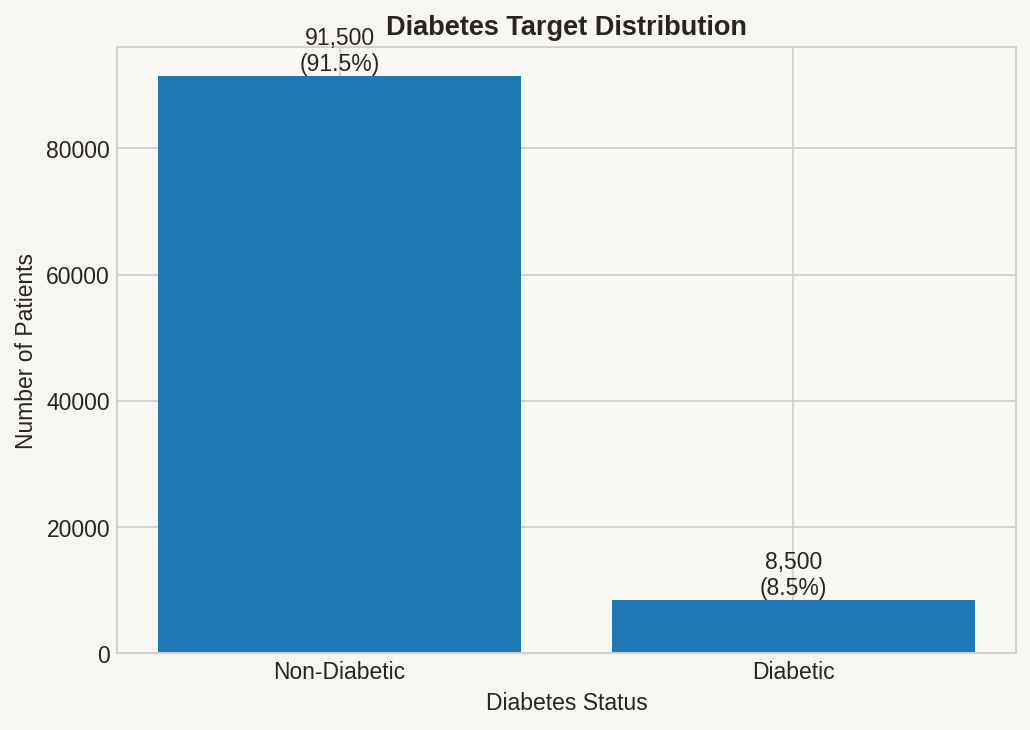

In [96]:
dist_pd = target_dist.toPandas()

dist_pd["status"] = dist_pd["diabetes"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    dist_pd["status"],
    dist_pd["patient_count"]
)

plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")

for bar, count, pct in zip(
    bars,
    dist_pd["patient_count"],
    dist_pd["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}\n({pct}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Age Distribution by Diabetes Status

In [97]:
# =========================================================
# CREATE AGE CATEGORIES
# =========================================================

df_age = (
    df.withColumn(
        "age_group",
        F.when(F.col("age") < 20, "0-19")
        .when(F.col("age") < 30, "20-29")
        .when(F.col("age") < 40, "30-39")
        .when(F.col("age") < 50, "40-49")
        .when(F.col("age") < 60, "50-59")
        .when(F.col("age") < 70, "60-69")
        .otherwise("70+")
    )
)

df_age.select(
    "age",
    "age_group",
    "diabetes"
).show(10)

+----+---------+--------+
| age|age_group|diabetes|
+----+---------+--------+
|80.0|      70+|       0|
|54.0|    50-59|       0|
|28.0|    20-29|       0|
|36.0|    30-39|       0|
|76.0|      70+|       0|
|20.0|    20-29|       0|
|44.0|    40-49|       1|
|79.0|      70+|       0|
|42.0|    40-49|       0|
|32.0|    30-39|       0|
+----+---------+--------+
only showing top 10 rows


In [98]:
age_summary = (
    df_age.groupBy("age_group")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(
            F.col("diabetic") / F.col("total") * 100,
            2
        )
    )
)

age_summary.show()

+---------+-----+--------+-------------------+
|age_group|total|diabetic|diabetes_percentage|
+---------+-----+--------+-------------------+
|    30-39|13052|     436|               3.34|
|      70+|13275|    2673|              20.14|
|    20-29|12767|     168|               1.32|
|    60-69|11780|    2259|              19.18|
|     0-19|19668|     106|               0.54|
|    40-49|14595|     999|               6.84|
|    50-59|14863|    1859|              12.51|
+---------+-----+--------+-------------------+



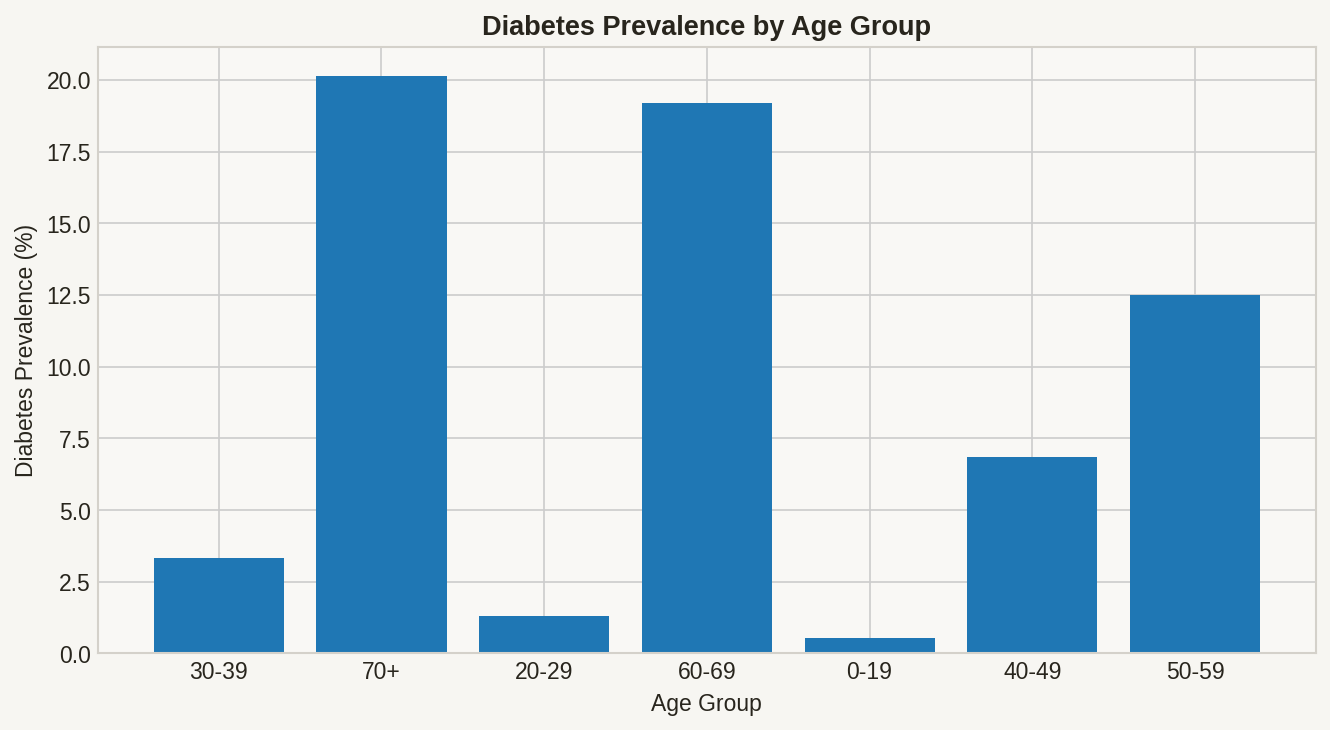

In [101]:
age_pd = age_summary.toPandas()

plt.figure(figsize=(9,5))

plt.bar(
    age_pd["age_group"],
    age_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Prevalence (%)")

plt.tight_layout()
plt.show()

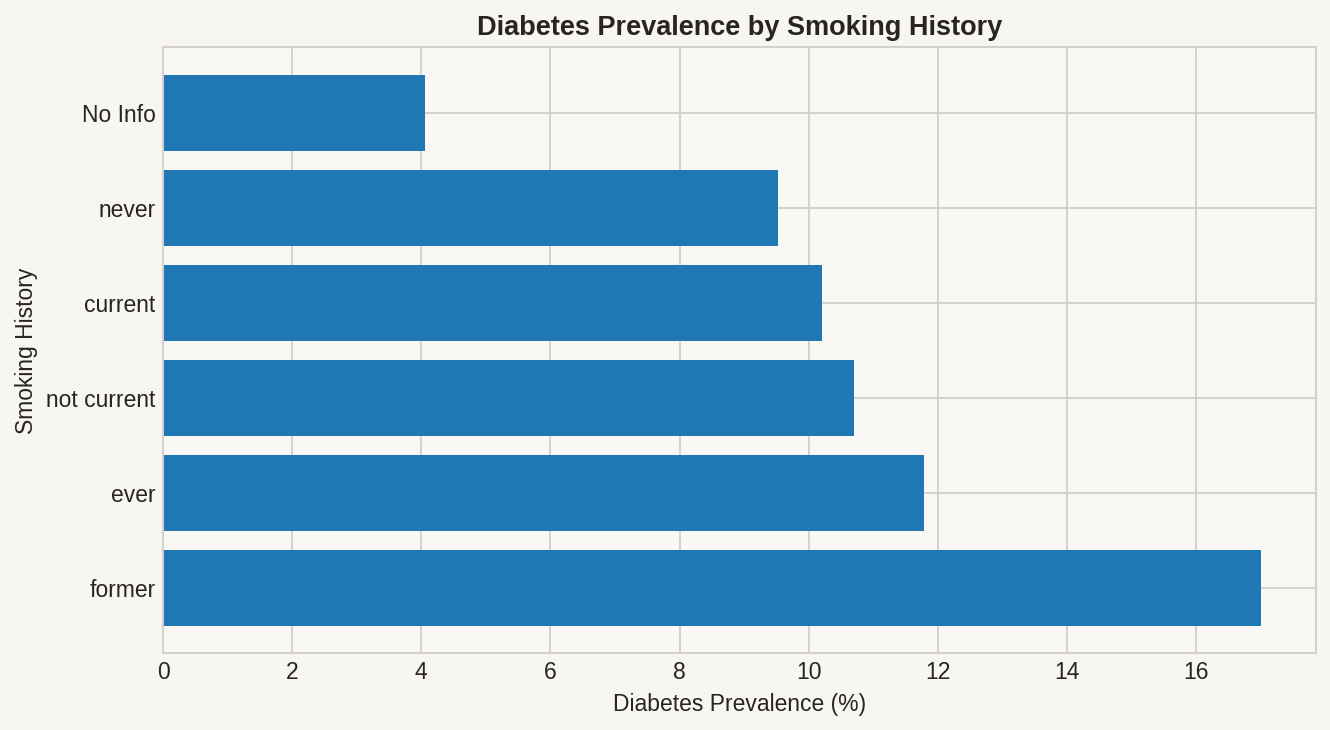

In [103]:
from pyspark.sql import functions as F

smoking_summary = (
    df.groupBy("smoking_history")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(
            F.col("diabetic") / F.col("total") * 100,
            2
        )
    )
    .orderBy(F.col("diabetes_percentage").desc())
)

smoking_pd = smoking_summary.toPandas()

plt.figure(figsize=(9,5))

plt.barh(
    smoking_pd["smoking_history"],
    smoking_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by Smoking History")
plt.xlabel("Diabetes Prevalence (%)")
plt.ylabel("Smoking History")

plt.tight_layout()
plt.show()

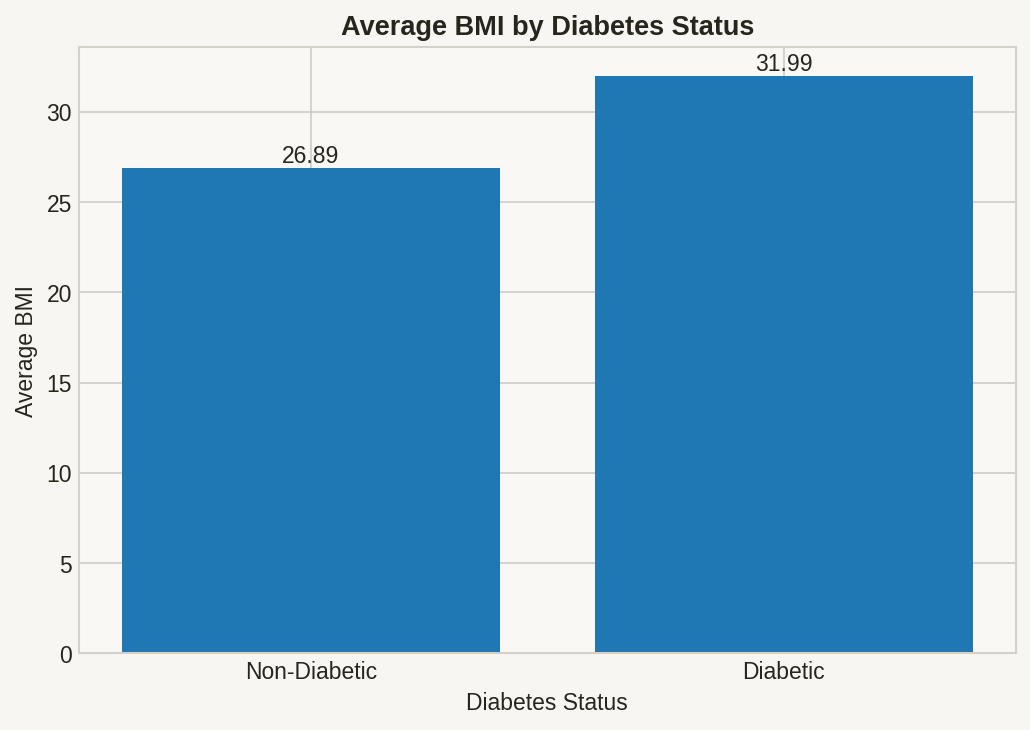

In [106]:
from pyspark.sql import functions as F

bmi_summary = df.groupBy("diabetes").agg(
    F.round(F.avg("bmi"), 2).alias("average_bmi")
).orderBy("diabetes")

bmi_pd = bmi_summary.toPandas()

bmi_pd["status"] = bmi_pd["diabetes"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    bmi_pd["status"],
    bmi_pd["average_bmi"]
)

plt.title("Average BMI by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Average BMI")

for bar, value in zip(
    bars,
    bmi_pd["average_bmi"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [72]:
#. Identify null/missing values for each column
for column in df.columns:
    null_count = df.filter(df[column].isNull()).count()
    print(column, ":", null_count)

gender : 0
age : 0
hypertension : 0
heart_disease : 0
smoking_history : 0
bmi : 0
HbA1c_level : 0
blood_glucose_level : 0
diabetes : 0


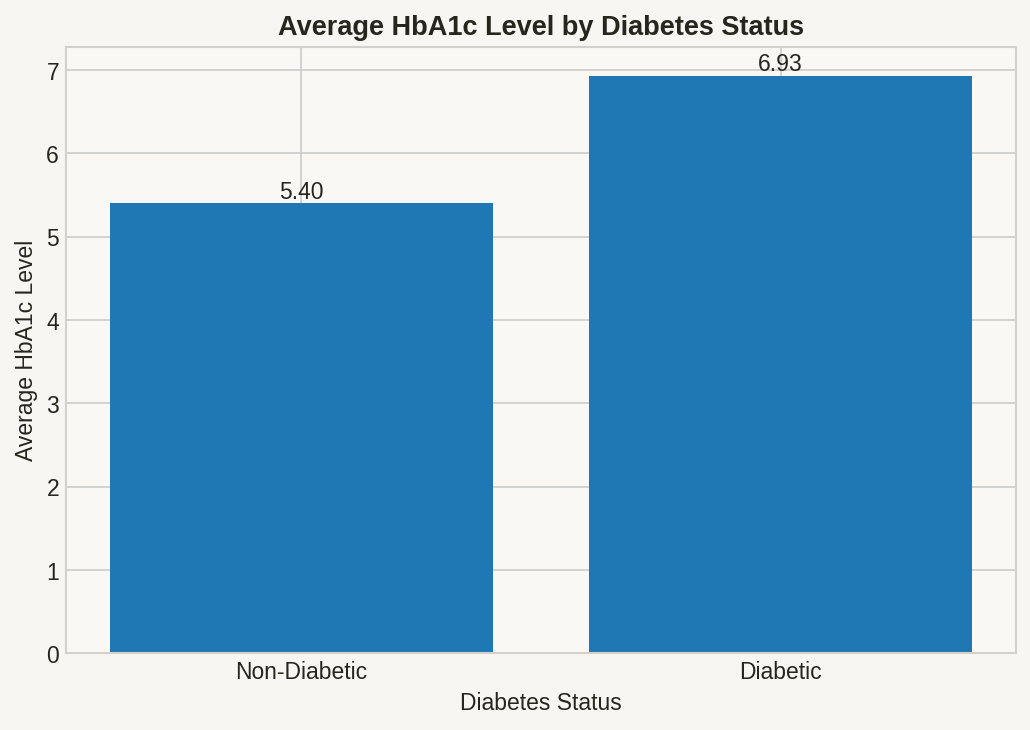

In [109]:
from pyspark.sql import functions as F

hba1c_summary = df.groupBy("diabetes").agg(
    F.round(F.avg("HbA1c_level"), 2).alias("average_HbA1c")
).orderBy("diabetes")

hba1c_pd = hba1c_summary.toPandas()

hba1c_pd["status"] = hba1c_pd["diabetes"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    hba1c_pd["status"],
    hba1c_pd["average_HbA1c"]
)

plt.title("Average HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Average HbA1c Level")

for bar, value in zip(
    bars,
    hba1c_pd["average_HbA1c"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

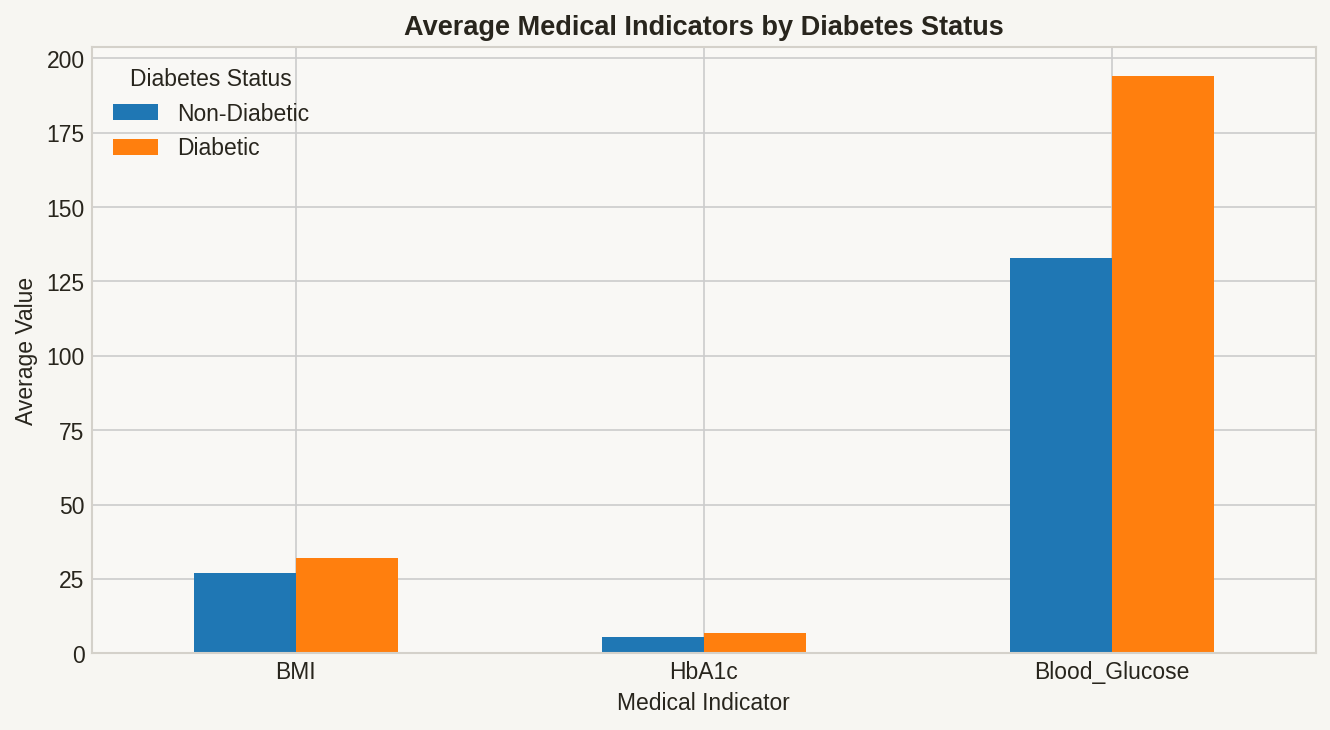

In [111]:
from pyspark.sql import functions as F

medical_summary = df.groupBy("diabetes").agg(
    F.round(F.avg("bmi"), 2).alias("BMI"),
    F.round(F.avg("HbA1c_level"), 2).alias("HbA1c"),
    F.round(F.avg("blood_glucose_level"), 2).alias("Blood_Glucose")
).orderBy("diabetes")

medical_pd = medical_summary.toPandas()

medical_pd["status"] = medical_pd["diabetes"].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})

medical_plot = medical_pd.set_index("status")[
    ["BMI", "HbA1c", "Blood_Glucose"]
].T

medical_plot.plot(
    kind="bar",
    figsize=(9,5),
    rot=0
)

plt.title("Average Medical Indicators by Diabetes Status")
plt.xlabel("Medical Indicator")
plt.ylabel("Average Value")
plt.legend(title="Diabetes Status")

plt.tight_layout()
plt.show()

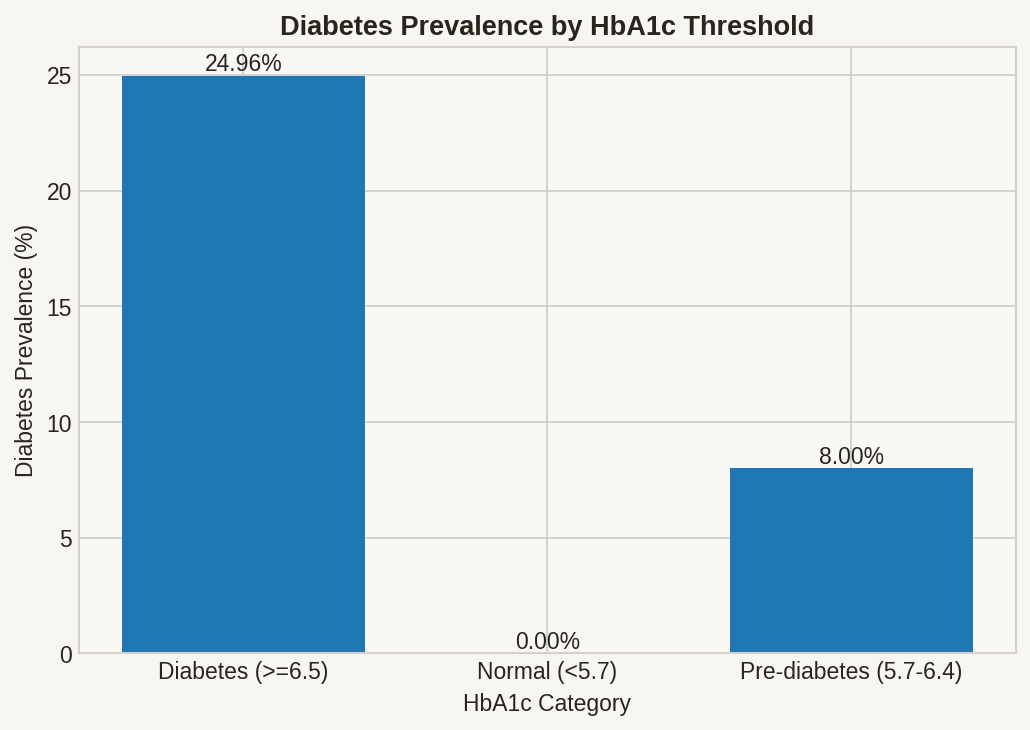

In [113]:
from pyspark.sql import functions as F

# Define HbA1c categories
df_with_hba1c_category = df.withColumn(
    "HbA1c_category",
    F.when(F.col("HbA1c_level") < 5.7, "Normal (<5.7)")
    .when(F.col("HbA1c_level").between(5.7, 6.4), "Pre-diabetes (5.7-6.4)")
    .otherwise("Diabetes (>=6.5)")
)

# Calculate summary for HbA1c thresholds
hba_threshold_summary = (
    df_with_hba1c_category.groupBy("HbA1c_category")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(F.col("diabetic") / F.col("total") * 100, 2)
    )
    .orderBy("HbA1c_category")
)

# Rename the column for consistency with the plotting code
hba_threshold_summary = hba_threshold_summary.withColumnRenamed("HbA1c_category", "HbA1c_threshold")

hba_threshold_pd = hba_threshold_summary.toPandas()

plt.figure(figsize=(7,5))

bars = plt.bar(
    hba_threshold_pd["HbA1c_threshold"],
    hba_threshold_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by HbA1c Threshold")
plt.xlabel("HbA1c Category")
plt.ylabel("Diabetes Prevalence (%)")

for bar, value in zip(
    bars,
    hba_threshold_pd["diabetes_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

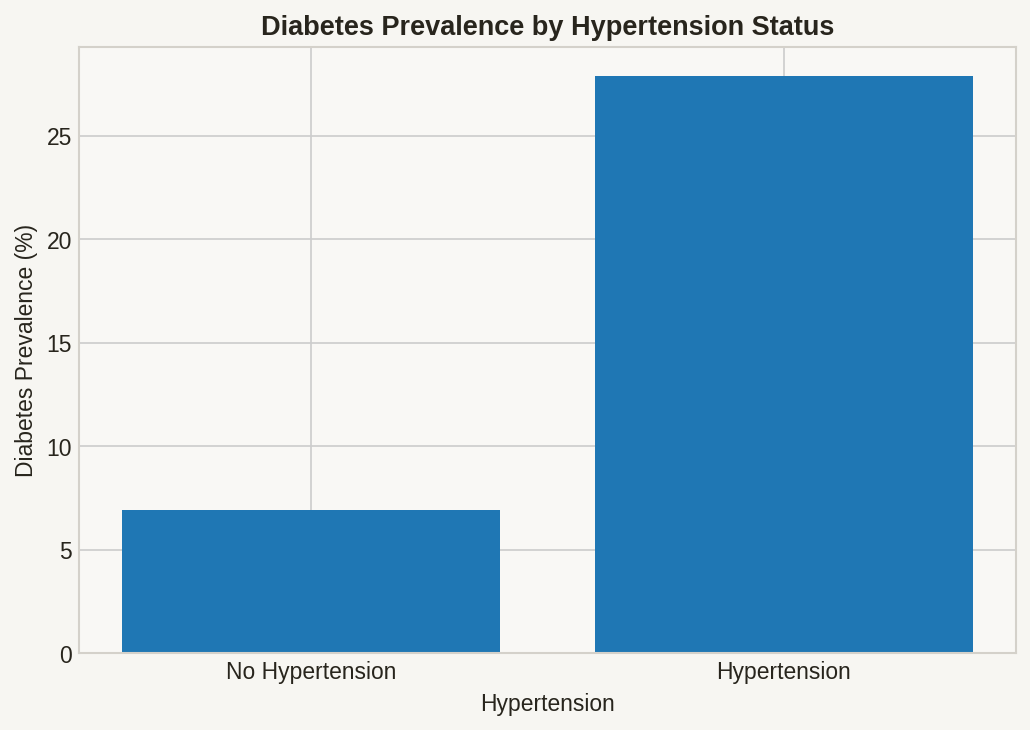

In [115]:
from pyspark.sql import functions as F

hypertension_summary = (
    df.groupBy("hypertension")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(F.col("diabetic") / F.col("total") * 100, 2)
    )
    .orderBy("hypertension")
)

hypertension_pd = hypertension_summary.toPandas()

hypertension_pd["status"] = hypertension_pd[
    "hypertension"
].map({
    0: "No Hypertension",
    1: "Hypertension"
})

plt.figure(figsize=(7,5))

plt.bar(
    hypertension_pd["status"],
    hypertension_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by Hypertension Status")
plt.xlabel("Hypertension")
plt.ylabel("Diabetes Prevalence (%)")

plt.tight_layout()
plt.show()

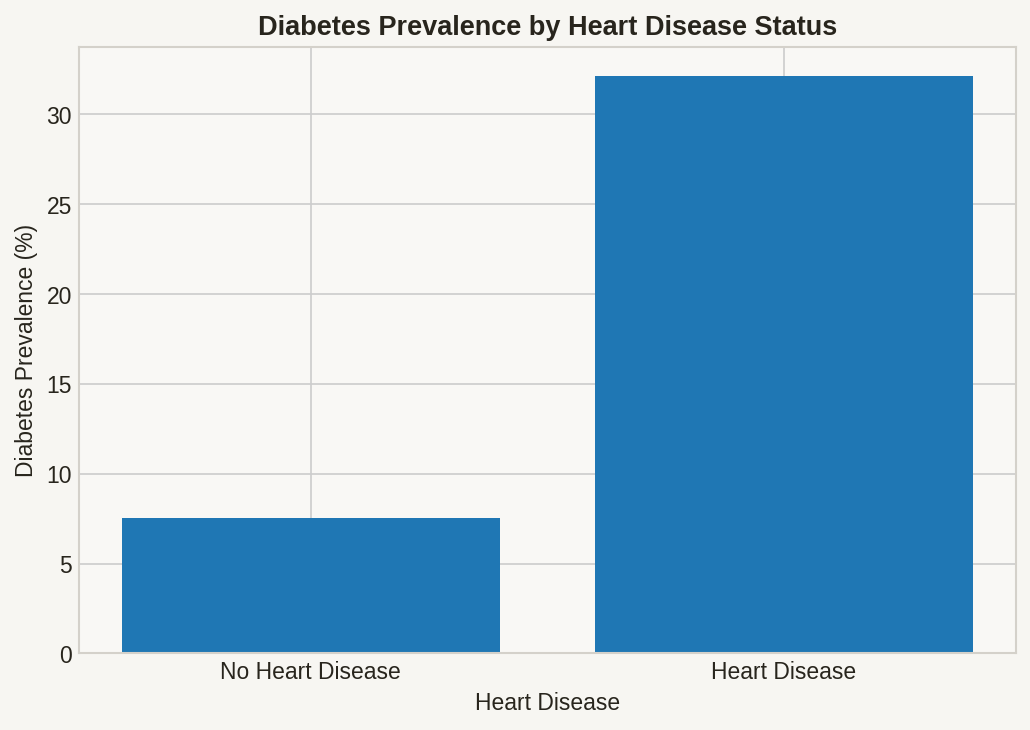

In [117]:
from pyspark.sql import functions as F

heart_summary = (
    df.groupBy("heart_disease")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(F.col("diabetic") / F.col("total") * 100, 2)
    )
    .orderBy("heart_disease")
)

heart_pd = heart_summary.toPandas()

heart_pd["status"] = heart_pd[
    "heart_disease"
].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

plt.figure(figsize=(7,5))

plt.bar(
    heart_pd["status"],
    heart_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Diabetes Prevalence (%)")

plt.tight_layout()
plt.show()

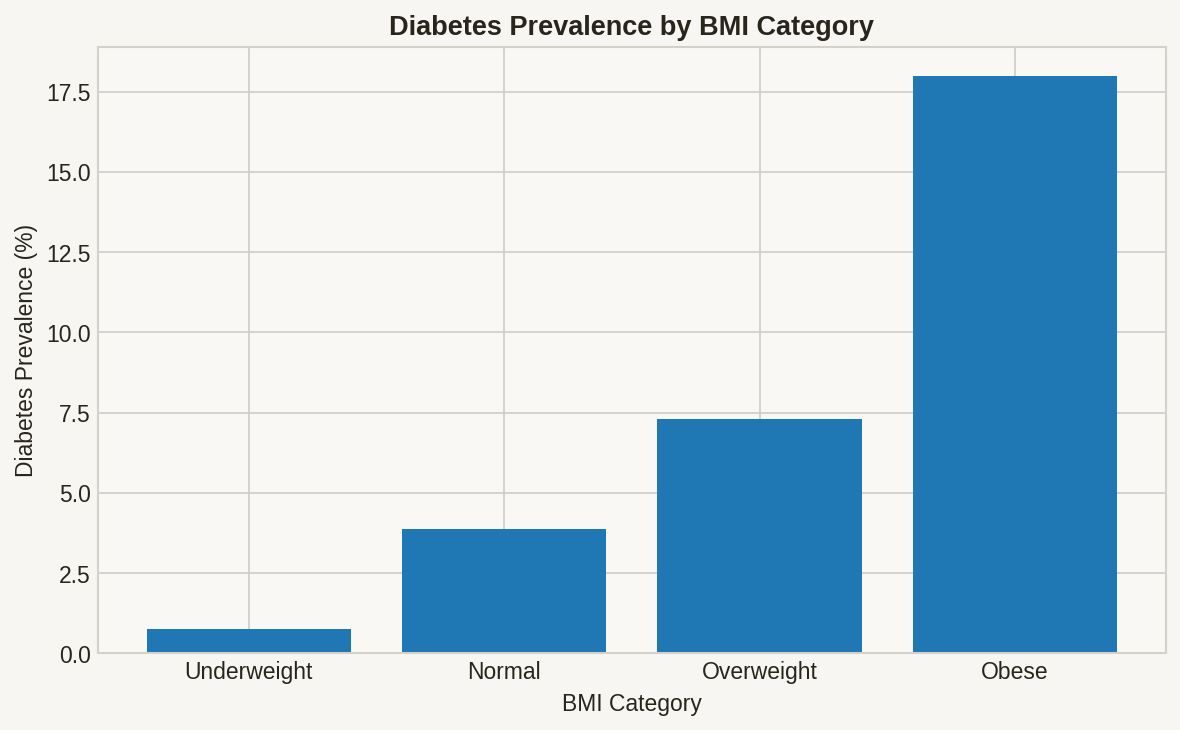

In [121]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

bmi_category_summary = (
    df.groupBy("bmi_category")
    .agg(
        F.count("*").alias("total"),
        F.sum("diabetes").alias("diabetic")
    )
    .withColumn(
        "diabetes_percentage",
        F.round(F.col("diabetic") / F.col("total") * 100, 2)
    )
)

bmi_cat_pd = bmi_category_summary.toPandas()

bmi_order = [
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
]

bmi_cat_pd["bmi_category"] = pd.Categorical(
    bmi_cat_pd["bmi_category"],
    categories=bmi_order,
    ordered=True
)

bmi_cat_pd = bmi_cat_pd.sort_values(
    "bmi_category"
)

plt.figure(figsize=(8,5))

plt.bar(
    bmi_cat_pd["bmi_category"],
    bmi_cat_pd["diabetes_percentage"]
)

plt.title("Diabetes Prevalence by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Diabetes Prevalence (%)")

plt.tight_layout()
plt.show()

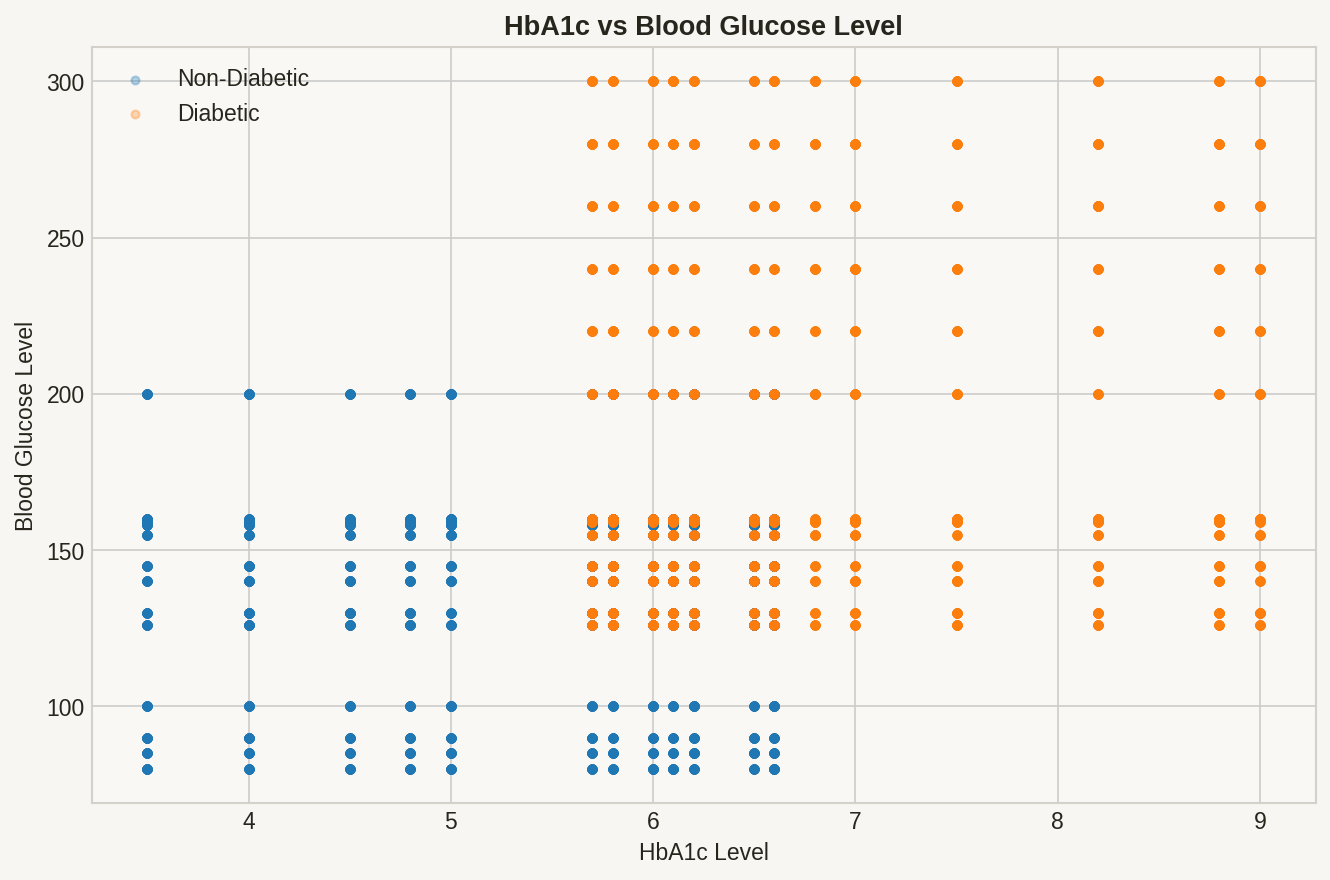

In [122]:
plt.figure(figsize=(9,6))

for status, label in [
    (0, "Non-Diabetic"),
    (1, "Diabetic")
]:

    subset = sample_pd[
        sample_pd["diabetes"] == status
    ]

    plt.scatter(
        subset["HbA1c_level"],
        subset["blood_glucose_level"],
        alpha=0.3,
        s=15,
        label=label
    )

plt.title("HbA1c vs Blood Glucose Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Blood Glucose Level")
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
df.createOrReplaceTempView("diabetes")

#. Target Distribution

spark.sql("""
    SELECT diabetes,
           COUNT(*) AS patient_count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM diabetes), 2) AS percentage
    FROM diabetes
    GROUP BY diabetes
    ORDER BY diabetes
""").show()

+--------+-------------+----------+
|diabetes|patient_count|percentage|
+--------+-------------+----------+
|       0|        91500|     91.50|
|       1|         8500|      8.50|
+--------+-------------+----------+



Exploratory Data Analysis (EDA) of diabetes_prediction_dataset.csv
Entirely using PySpark DataFrame operations and SQL functions.

Sections:
1. Target Variable Distribution (class imbalance)
2. Demographic Analysis (gender, age, smoking history)
3. Medical Indicators Analysis (BMI, HbA1c, blood glucose, hypertension/heart disease co-occurrence)
4. Correlation Insights (HbA1c vs blood glucose, BMI categories vs diabetes across age groups)

In [79]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("DiabetesPredictionEDA")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

csv_path = "/content/diabetes_prediction_dataset.csv"
df = spark.read.csv(csv_path, header=True, inferSchema=True)
df.createOrReplaceTempView("diabetes")

total_rows = df.count()

def banner(title):
    print(f"\n{'=' * 20} {title} {'=' * 20}")

TARGET VARIABLE DISTRIBUTION

In [75]:
import builtins

banner("1. Target Variable Distribution")

target_dist = (
    df.groupBy("diabetes")
    .agg(F.count("*").alias("patient_count"))
    .withColumn("percentage", F.round(F.col("patient_count") / total_rows * 100, 2))
    .orderBy("diabetes")
)
target_dist.show()

counts = {row["diabetes"]: row["patient_count"] for row in target_dist.collect()}
non_diabetic = counts.get(0, 0)
diabetic = counts.get(1, 0)
imbalance_ratio = builtins.round(non_diabetic / diabetic, 2) if diabetic else None
print(f"Non-diabetic (0): {non_diabetic}  |  Diabetic (1): {diabetic}")
print(f"Class imbalance ratio (non-diabetic : diabetic) = {imbalance_ratio} : 1")

# Same result via Spark SQL
banner("1b. Target Distribution via Spark SQL")
spark.sql("""
    SELECT diabetes,
           COUNT(*) AS patient_count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM diabetes), 2) AS percentage
    FROM diabetes
    GROUP BY diabetes
    ORDER BY diabetes
""").show()


==================== 1. Target Variable Distribution ====================
+--------+-------------+----------+
|diabetes|patient_count|percentage|
+--------+-------------+----------+
|       0|        91500|      91.5|
|       1|         8500|       8.5|
+--------+-------------+----------+

Non-diabetic (0): 91500  |  Diabetic (1): 8500
Class imbalance ratio (non-diabetic : diabetic) = 10.76 : 1

==================== 1b. Target Distribution via Spark SQL ====================
+--------+-------------+----------+
|diabetes|patient_count|percentage|
+--------+-------------+----------+
|       0|        91500|     91.50|
|       1|         8500|      8.50|
+--------+-------------+----------+



DEMOGRAPHIC ANALYSIS

In [76]:
banner("2a. Gender Distribution by Diabetes Status (groupBy)")
df.groupBy("gender", "diabetes").agg(F.count("*").alias("count")) \
  .orderBy("gender", "diabetes").show()

banner("2b. Gender x Diabetes Crosstab")
df.crosstab("gender", "diabetes").show()

banner("2c. Age Distribution Summary by Diabetes Status")
df.groupBy("diabetes").agg(
    F.round(F.avg("age"), 2).alias("avg_age"),
    F.round(F.min("age"), 2).alias("min_age"),
    F.round(F.max("age"), 2).alias("max_age"),
    F.round(F.expr("percentile_approx(age, 0.5)"), 2).alias("median_age"),
).orderBy("diabetes").show()

# Bucket age into groups for a clearer crosstab
df = df.withColumn(
    "age_group",
    F.when(F.col("age") < 18, "0-17")
     .when(F.col("age") < 30, "18-29")
     .when(F.col("age") < 45, "30-44")
     .when(F.col("age") < 60, "45-59")
     .when(F.col("age") < 75, "60-74")
     .otherwise("75+")
)
df.createOrReplaceTempView("diabetes")  # refresh view with age_group column

banner("2d. Age Group x Diabetes Crosstab")
df.crosstab("age_group", "diabetes").orderBy("age_group_diabetes").show()

banner("2e. Smoking History Breakdown by Diabetes Status")
smoking_breakdown = (
    df.groupBy("smoking_history", "diabetes")
    .agg(F.count("*").alias("count"))
    .orderBy("smoking_history", "diabetes")
)
smoking_breakdown.show(20)

banner("2f. Smoking History - Diabetes Rate (%) via SQL")
spark.sql("""
    SELECT smoking_history,
           COUNT(*) AS total_patients,
           SUM(diabetes) AS diabetic_patients,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY smoking_history
    ORDER BY diabetes_rate_pct DESC
""").show()


==================== 2a. Gender Distribution by Diabetes Status (groupBy) ====================
+------+--------+-----+
|gender|diabetes|count|
+------+--------+-----+
|Female|       0|54091|
|Female|       1| 4461|
|  Male|       0|37391|
|  Male|       1| 4039|
| Other|       0|   18|
+------+--------+-----+


==================== 2b. Gender x Diabetes Crosstab ====================
+---------------+-----+----+
|gender_diabetes|    0|   1|
+---------------+-----+----+
|         Female|54091|4461|
|          Other|   18|   0|
|           Male|37391|4039|
+---------------+-----+----+


==================== 2c. Age Distribution Summary by Diabetes Status ====================
+--------+-------+-------+-------+----------+
|diabetes|avg_age|min_age|max_age|median_age|
+--------+-------+-------+-------+----------+
|       0|  40.12|   0.08|   80.0|      40.0|
|       1|  60.95|    3.0|   80.0|      62.0|
+--------+-------+-------+-------+----------+


==================== 2d. Age Group x Dia

MEDICAL INDICATORS ANALYSIS

In [77]:
banner("3a. Avg BMI / HbA1c / Blood Glucose by Diabetes Status")
df.groupBy("diabetes").agg(
    F.round(F.avg("bmi"), 2).alias("avg_bmi"),
    F.round(F.avg("HbA1c_level"), 2).alias("avg_HbA1c"),
    F.round(F.avg("blood_glucose_level"), 2).alias("avg_blood_glucose"),
).orderBy("diabetes").show()

banner("3b. Clinical HbA1c Threshold Flag (> 6.5)")
df = df.withColumn("high_HbA1c_flag", F.when(F.col("HbA1c_level") > 6.5, 1).otherwise(0))
df.createOrReplaceTempView("diabetes")

spark.sql("""
    SELECT high_HbA1c_flag,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY high_HbA1c_flag
    ORDER BY high_HbA1c_flag
""").show()

banner("3c. Hypertension Co-occurrence with Diabetes")
spark.sql("""
    SELECT hypertension,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY hypertension
    ORDER BY hypertension
""").show()

banner("3d. Heart Disease Co-occurrence with Diabetes")
spark.sql("""
    SELECT heart_disease,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY heart_disease
    ORDER BY heart_disease
""").show()

banner("3e. Combined Hypertension + Heart Disease vs Diabetes")
spark.sql("""
    SELECT hypertension, heart_disease,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY hypertension, heart_disease
    ORDER BY hypertension, heart_disease
""").show()


==================== 3a. Avg BMI / HbA1c / Blood Glucose by Diabetes Status ====================
+--------+-------+---------+-----------------+
|diabetes|avg_bmi|avg_HbA1c|avg_blood_glucose|
+--------+-------+---------+-----------------+
|       0|  26.89|      5.4|           132.85|
|       1|  31.99|     6.93|           194.09|
+--------+-------+---------+-----------------+


==================== 3b. Clinical HbA1c Threshold Flag (> 6.5) ====================
+---------------+-------------+--------------+-----------------+
|high_HbA1c_flag|patient_count|diabetic_count|diabetes_rate_pct|
+---------------+-------------+--------------+-----------------+
|              0|        87565|          3922|             4.48|
|              1|        12435|          4578|            36.82|
+---------------+-------------+--------------+-----------------+


==================== 3c. Hypertension Co-occurrence with Diabetes ====================
+------------+-------------+--------------+------------

CORRELATION INSIGHTS

In [78]:
# Re-load df from the temporary view to ensure it's linked to the active SparkSession
df = spark.table("diabetes")

banner("4a. Correlation: HbA1c_level vs blood_glucose_level")
corr_hba1c_glucose = df.stat.corr("HbA1c_level", "blood_glucose_level")
print(f"Pearson correlation (HbA1c_level, blood_glucose_level) = {corr_hba1c_glucose:.4f}")

banner("4b. Correlation of Numeric Features with Diabetes")
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level", "hypertension", "heart_disease"]
for c in numeric_cols:
    corr_val = df.stat.corr(c, "diabetes")
    print(f"corr({c:>20}, diabetes) = {corr_val:.4f}")

banner("4c. BMI Categories (Clinical Bands)")
df = df.withColumn(
    "bmi_category",
    F.when(F.col("bmi") < 18.5, "Underweight")
     .when(F.col("bmi") < 25, "Normal")
     .when(F.col("bmi") < 30, "Overweight")
     .otherwise("Obese")
)
df.createOrReplaceTempView("diabetes")

banner("4d. Diabetes Prevalence by BMI Category")
spark.sql("""
    SELECT bmi_category,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY bmi_category
    ORDER BY diabetes_rate_pct DESC
""").show()

banner("4e. Diabetes Prevalence by BMI Category ACROSS Age Groups")
spark.sql("""
    SELECT age_group, bmi_category,
           COUNT(*) AS patient_count,
           SUM(diabetes) AS diabetic_count,
           ROUND(SUM(diabetes) * 100.0 / COUNT(*), 2) AS diabetes_rate_pct
    FROM diabetes
    GROUP BY age_group, bmi_category
    ORDER BY age_group, bmi_category
""").show(30)

print("\nEDA complete.")


==================== 4a. Correlation: HbA1c_level vs blood_glucose_level ====================
Pearson correlation (HbA1c_level, blood_glucose_level) = 0.1667

==================== 4b. Correlation of Numeric Features with Diabetes ====================
corr(                 age, diabetes) = 0.2580
corr(                 bmi, diabetes) = 0.2144
corr(         HbA1c_level, diabetes) = 0.4007
corr( blood_glucose_level, diabetes) = 0.4196
corr(        hypertension, diabetes) = 0.1978
corr(       heart_disease, diabetes) = 0.1717

==================== 4c. BMI Categories (Clinical Bands) ====================

==================== 4d. Diabetes Prevalence by BMI Category ====================
+------------+-------------+--------------+-----------------+
|bmi_category|patient_count|diabetic_count|diabetes_rate_pct|
+------------+-------------+--------------+-----------------+
|       Obese|        23536|          4233|            17.99|
|  Overweight|        45751|          3340|             7.30|


Correlation Matrix Heatmap

In [123]:
# CREATE CORRELATION MATRIX USING PYSPARK

correlation_columns = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "diabetes"
]

correlation_matrix = []

for col1 in correlation_columns:

    row = []

    for col2 in correlation_columns:

        corr_value = df.stat.corr(
            col1,
            col2
        )

        row.append(corr_value)

    correlation_matrix.append(row)

In [124]:
corr_pd = pd.DataFrame(
    correlation_matrix,
    columns=correlation_columns,
    index=correlation_columns
)

corr_pd

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


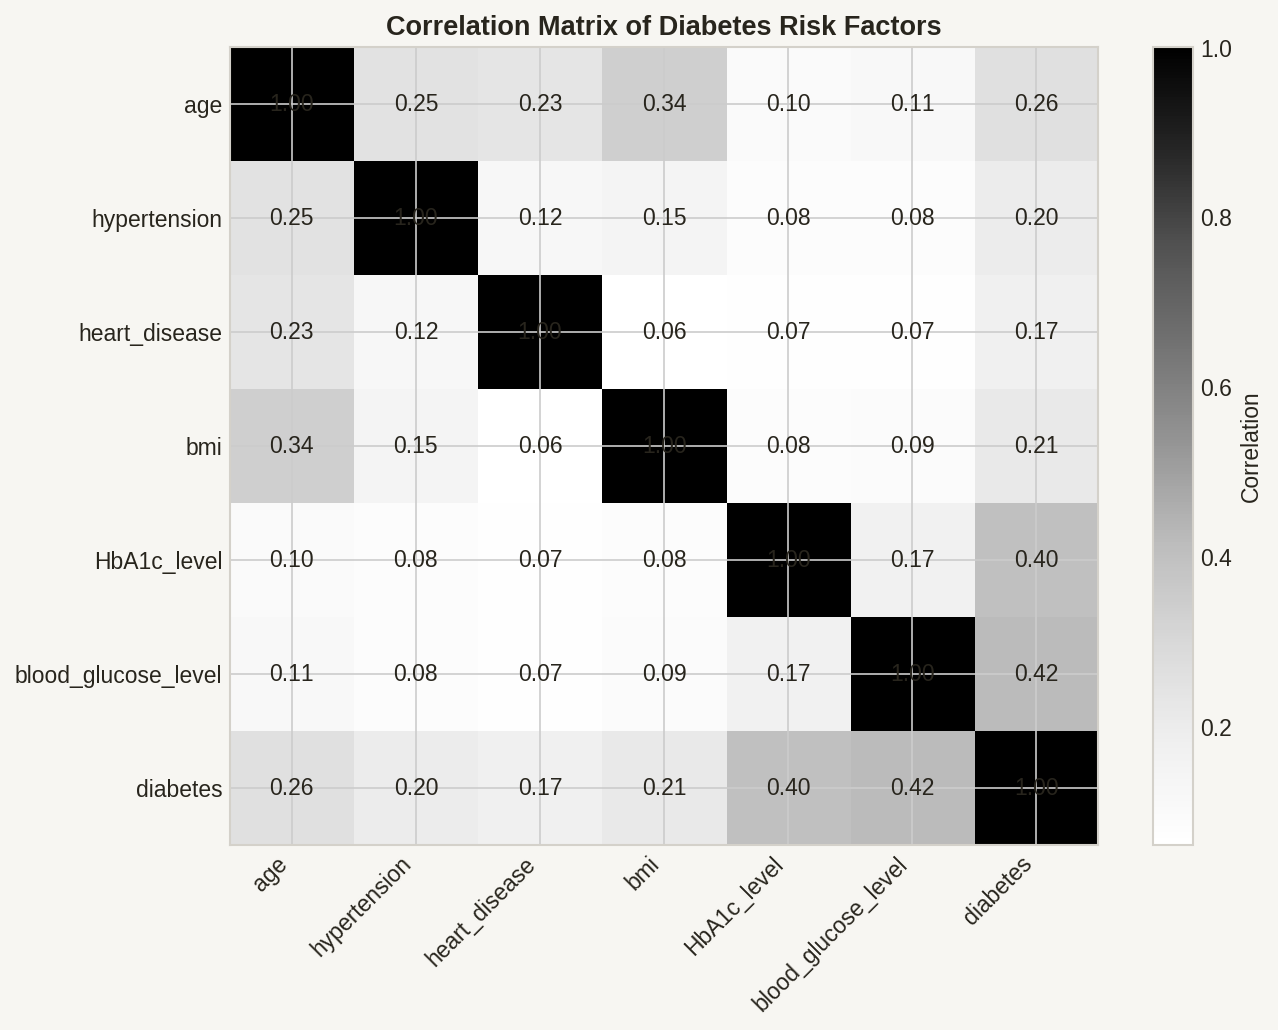

In [125]:
plt.figure(figsize=(9,7))

plt.imshow(
    corr_pd,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):

    for j in range(len(correlation_columns)):

        plt.text(
            j,
            i,
            f"{corr_pd.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Diabetes Risk Factors")

plt.tight_layout()
plt.show()